In [ ]:
MIN_EPSILON = 17
from util.gg import GridSynthGate
from bqskit.ir.gates import RZGate
import numpy as np
from util import get_approx_t_str, gridsynth_gates_to_cir
from bqskit.qis.pauli import PauliMatrices
from util import gp_frobenius_cost, get_corrected_un, frobenius_cost

def get_az(H):
    """
    Computes a Pauli expansion of the hermitian matrix H.

    Args:
        H (np.ndarray): The hermitian matrix to expand.

    Returns:
        np.ndarray: The coefficients of a Pauli expansion for H,
        i.e., X dot Sigma = H where Sigma is Pauli matrices of
        same size of H.

    Note:
        This assumes the input is hermitian but does not check. The
        output is undefined on non-hermitian inputs.
    """

    # Change basis of H to Pauli Basis (solve for coefficients -> X)
    n = int(np.log2(len(H)))
    paulis = PauliMatrices(n)
    flatten_paulis = [np.reshape(pauli, 4 ** n) for pauli in paulis]
    flatten_H = np.reshape(H, 4 ** n)
    A = np.stack(flatten_paulis, axis=-1)
    X = np.matmul(np.linalg.inv(A), flatten_H)

    # Want to make the first coefficient real
    global_phase = np.angle(X[0])
    X = np.exp(-1j * global_phase) * X

    # Return imaginary part of the last coefficient
    return np.imag(X[-1])


def get_rz_perturbation_params_test(starting_angle, 
                                     epsilon: int) -> tuple[list[list[float]],
                                                                list[float]]:
    '''
    Return a list of params 
    '''
    if epsilon > MIN_EPSILON:
        # Try with epsilon
        epsilon = MIN_EPSILON

    V = RZGate().get_unitary([starting_angle])
    U_1_t_str = get_approx_t_str(starting_angle, epsilon)
    U_1_t_circ = gridsynth_gates_to_cir(U_1_t_str)
    U_1 = U_1_t_circ.get_unitary()

    final_strs = []
    final_params = []
    final_params.append([starting_angle, epsilon, 0])

    final_strs.append(U_1_t_str)

    Vt_U_1 = V.conj().T @ U_1

    az = get_az(Vt_U_1)

    float_epsilon = 10.0 ** (-epsilon)
    delta = 2 * np.arcsin(float_epsilon)
    if az < 0:
        delta = -delta

    U_2_t_str = get_approx_t_str(starting_angle + delta, epsilon)
    U_2_t_circ = gridsynth_gates_to_cir(U_2_t_str)
    U_2 = U_2_t_circ.get_unitary()

    final_params.append([starting_angle + delta, epsilon, 0])
    final_strs.append(U_2_t_str)

    Vt_U_2 = V.conj().T @ U_2
    Bz = get_az(Vt_U_2)

    q = az / (az - Bz)

    p2 = q / 2
    p1 = (1 - q) / 2

    if np.allclose(p1, 0, atol=1e-5):
        p1 = 0
        p2 = 0.5
    elif np.allclose(p2, 0, atol=1e-5):
        p1 = 0.5
        p2 = 0

    probs = [p1, p2] * 2
    final_params.append([starting_angle, epsilon, 1])
    final_params.append([starting_angle + delta, epsilon, 1])
    return final_params, final_strs, probs

In [2]:
angle = 3
orig_unitary = RZGate().get_unitary([angle])
# print(orig_unitary)
gg_params, gg_strs, probs = get_rz_perturbation_params_test(angle, 9)

print(gg_params)
print(len(gg_strs))

[[3, 9, 0], [2.999999998, 9, 0], [3, 9, 1], [2.999999998, 9, 1]]
2


In [2]:
import numpy as np

def calculate_scaling_factor(angle: float, epsilon: int) -> float:
    """
    Calculate the bias reduction for a given angle and epsilon.
    """
    orig_unitary = RZGate().get_unitary([angle])
    # print(orig_unitary)
    gg_params, gg_strs, probs = get_rz_perturbation_params_test(angle, epsilon)

    gg_cache = {}
    for i, gg_str in enumerate(gg_strs):
        ind = (gg_params[i][0], gg_params[i][1])
        gg_cache[ind] = gg_str

    print(list(gg_cache.keys()))
    uns = [GridSynthGate().get_unitary(gg_param, local_cache=gg_cache) for gg_param in gg_params]
    # Correct for global phase
    uns = [get_corrected_un(u, orig_unitary) for u in uns]
    # sampled_inds = np.random.choice(len(uns), size=10000, p=probs)
    # sampled_uns = [uns[i] for i in sampled_inds]
    costs = [gp_frobenius_cost(un, orig_unitary) for un in uns]
    # avg_cost = np.mean([gp_frobenius_cost(sampled_u, orig_unitary) for sampled_u in sampled_uns])
    avg_cost = np.mean(costs)
    # avg_un = np.mean(sampled_uns, axis=0)
    avg_un = np.average(uns, axis=0, weights=probs)
    bias = gp_frobenius_cost(avg_un, orig_unitary)

    scaling_factor = bias / avg_cost / avg_cost

    return scaling_factor

In [6]:
calculate_scaling_factor(0.6, 9)

[(0.6, 9), (0.5999999979999999, 9)]
[(0.6, 9), (0.5999999979999999, 9)]
(0.6, 9)
[(0.6, 9), (0.5999999979999999, 9)]
(0.5999999979999999, 9)
[(0.6, 9), (0.5999999979999999, 9)]
(0.6, 9)
[(0.6, 9), (0.5999999979999999, 9)]
(0.5999999979999999, 9)


1944.319872162684

In [59]:
# calculate_scaling_factor(0.3, 4)
rand_angles = np.random.uniform(0, 2 * np.pi, 20)
rand_epsilons = range(1, 10)
scaling_factors = []
for ang in rand_angles:
    for eps in rand_epsilons:
        scaling_factor = calculate_scaling_factor(ang, eps)
        scaling_factors.append((ang, eps, scaling_factor))

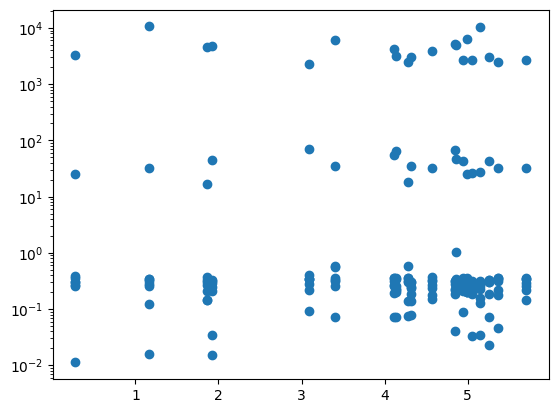

In [60]:
import matplotlib.pyplot as plt
# Plot scaling factor as a function of angle

angles = [a[0] for a in scaling_factors]
factors = [a[2] for a in scaling_factors]

# plt.scatter(angles, scaling_factors)
fig, ax = plt.subplots()
ax.scatter(angles, factors)
ax.set_yscale('log')

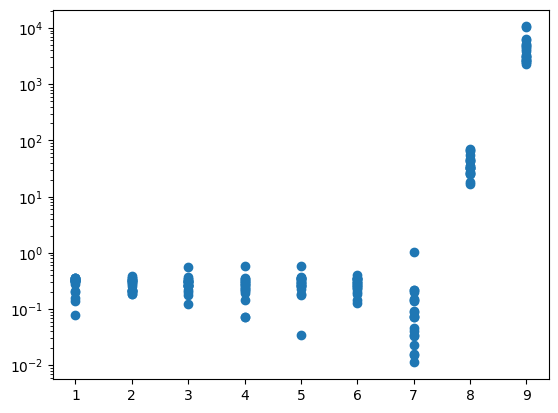

In [61]:
# Plot scaling factor as a function of epsilon
eps = [a[1] for a in scaling_factors]
fig, ax = plt.subplots()
ax.scatter(eps, factors)
# Draw line of best fit
ax.set_yscale('log')

In [ ]:
# Calculate epsilon improvement
def calculate_eps_improvement(angle: float, epsilon: int) -> float:
    """
    Calculate the bias reduction for a given angle and epsilon.
    """
    orig_unitary = RZGate().get_unitary([angle])
    gg_strs, probs = get_rz_perturbation_params(angle, epsilon)

    uns = [GridSynthGate().get_unitary(gg_param) for gg_param in gg_params]
    # Correct for global phase
    uns = np.array([get_corrected_un(u, orig_unitary) for u in uns])
    # sampled_inds = np.random.choice(len(uns), size=10000, p=probs)
    # sampled_uns = [uns[i] for i in sampled_inds]
    # avg_un = np.mean(sampled_uns, axis=0)
    # avg_un = np.dot(uns, probs)
    avg_un = np.tensordot(uns, probs, axes=(0, 0))
    bias = gp_frobenius_cost(avg_un, orig_unitary)

    # Find an epsilon that gives similar bias cost
    new_eps = epsilon * 2
    worse_eps_found = False
    while True:
        new_un = GridSynthGate().get_unitary([angle, new_eps, 0])
        new_cost = gp_frobenius_cost(new_un, orig_unitary)
        if new_cost < bias:
            if worse_eps_found:
                break
            else:
                new_eps -= 1
        elif new_cost > bias:
            new_eps += 1
            worse_eps_found = True


    return new_eps - epsilon

In [27]:
calculate_eps_improvement(0.7, 8)

1